In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    HuberRegressor
)
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


In [2]:
housing = fetch_california_housing(as_frame = True)

X = housing.data
y = housing.target

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
def contaminate_response(
    y,
    contamination_rate,
    multiplier = 5,
    random_state = None
):
    rng = np.random.default_rng(random_state)

    y_new = y.copy()

    n = len(y)

    n_outliers = int(contamination_rate * n)

    idx = rng.choice(n, size = n_outliers, replace = False)

    noise = rng.normal(
        loc = 0,
        scale = multiplier * np.std(y),
        size = n_outliers
    )

    y_new.iloc[idx] += noise

    return y_new

In [22]:
levels = [0, 0.05, 0.10, 0.20] # Contamination level

models = {
    "OLS": LinearRegression(),
    "Ridge": Ridge(alpha = 1.0),
    "LASSO": Lasso(alpha = 0.01),
    "Huber": HuberRegressor()
}

results = []
coef_results = []

feature_names = X.columns

In [23]:
n_repeat = 30

for rate in levels:

    for seed in range(n_repeat):

        # contamination
        y_train_cont = contaminate_response(
            y_train,
            contamination_rate=rate,
            multiplier=5,
            random_state=seed
        )

        for name, model in models.items():

            model.fit(
                X_train_scaled,
                y_train_cont
            )

            pred = model.predict(
                X_test_scaled
            )

            rmse = np.sqrt(
                mean_squared_error(
                    y_test,
                    pred
                )
            )

            mae = mean_absolute_error(
                y_test,
                pred
            )

            r2 = r2_score(
                y_test,
                pred
            )

            results.append({

                "Repeat": seed,

                "Model": name,

                "Contamination": rate,

                "RMSE": rmse,

                "MAE": mae,

                "R2": r2

            })

            coef_results.append({

                "Repeat": seed,

                "Model": name,

                "Contamination": rate,

                **dict(zip(feature_names, model.coef_))

            })

In [32]:
results_df = pd.DataFrame(results)
coef_df = pd.DataFrame(coef_results)

coef_df.head()

,Repeat,Model,Contamination,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,0,OLS,0.0,0.854383,0.122546,-0.294410,0.339259,-0.002308,-0.040829,-0.896929,-0.869842
1,0,Ridge,0.0,0.854327,0.122624,-0.294210,0.339008,-0.002282,-0.040833,-0.896168,-0.869071
2,0,LASSO,0.0,0.800957,0.127087,-0.162759,0.206207,-0.000000,-0.030602,-0.790113,-0.755674
3,0,Huber,0.0,0.917985,0.099691,-0.362750,0.408643,0.009198,-0.352517,-0.755679,-0.751968
4,1,OLS,0.0,0.854383,0.122546,-0.294410,0.339259,-0.002308,-0.040829,-0.896929,-0.869842


In [34]:
coef_summary = (
    coef_df
    .groupby(["Model", "Contamination"])
    .agg(["mean", "std"])
)

coef_summary.columns = [
    f"{feature}_{stat}"
    for feature, stat in coef_summary.columns
]

coef_summary = coef_summary.reset_index()

coef_summary.head()

,Model,Contamination,Repeat_mean,Repeat_std,MedInc_mean,MedInc_std,HouseAge_mean,HouseAge_std,AveRooms_mean,AveRooms_std,AveBedrms_mean,AveBedrms_std,Population_mean,Population_std,AveOccup_mean,AveOccup_std,Latitude_mean,Latitude_std,Longitude_mean,Longitude_std
0,Huber,0.00,14.5,8.803408,0.917985,0.000000,0.099691,0.000000,-0.362750,0.000000,0.408643,0.000000,0.009198,0.000000,-0.352517,0.000000,-0.755679,0.000000,-0.751968,0.000000
1,Huber,0.05,14.5,8.803408,0.916952,0.004777,0.100428,0.001942,-0.360397,0.008562,0.406367,0.008884,0.008479,0.001720,-0.265215,0.048712,-0.757718,0.006794,-0.754595,0.007107
2,Huber,0.10,14.5,8.803408,0.918679,0.006516,0.101717,0.003173,-0.362653,0.010613,0.409995,0.012350,0.007505,0.002631,-0.166767,0.050414,-0.757960,0.009340,-0.755405,0.009545
3,Huber,0.20,14.5,8.803408,0.915725,0.008303,0.104283,0.004759,-0.356144,0.015092,0.402632,0.014724,0.007157,0.004011,-0.087207,0.051477,-0.766174,0.015560,-0.762739,0.014418
4,LASSO,0.00,14.5,8.803408,0.800957,0.000000,0.127087,0.000000,-0.162759,0.000000,0.206207,0.000000,0.000000,0.000000,-0.030602,0.000000,-0.790113,0.000000,-0.755674,0.000000


In [30]:
summary_df = (
    results_df
    .groupby(
        ["Model", "Contamination"]
    )
    .agg({

        "RMSE": ["mean", "std"],

        "MAE": ["mean", "std"],

        "R2": ["mean", "std"]

    })
)

summary_df

RMSE                 MAE                  R2  \
                         mean       std      mean       std      mean   
Model Contamination                                                     
Huber 0.00           0.758445  0.000000  0.515846  0.000000  0.561024   
      0.05           0.758668  0.001720  0.517204  0.000705  0.560764   
      0.10           0.759948  0.002302  0.518929  0.000768  0.559278   
      0.20           0.758844  0.003118  0.520805  0.000891  0.560554   
LASSO 0.00           0.740442  0.000000  0.535326  0.000000  0.581615   
      0.05           0.740841  0.001619  0.535423  0.002453  0.581163   
      0.10           0.741866  0.002223  0.536611  0.002700  0.580002   
      0.20           0.742057  0.003005  0.538360  0.004832  0.579782   
OLS   0.00           0.745581  0.000000  0.533200  0.000000  0.575788   
      0.05           0.745774  0.002777  0.533316  0.002219  0.575562   
      0.10           0.747866  0.004033  0.534993  0.002788  0.573172   
      0.20           0.747426  0.004351  0.536496  0.004726  0.573672   
Ridge 0.00           0.745557  0.000000  0.533193  0.000000  0.575816   
      0.05           0.745750  0.002773  0.533308  0.002219  0.575590   
      0.10           0.747838  0.004026  0.534984  0.002787  0.573204   
      0.20           0.747399  0.004345  0.536487  0.004723  0.573703   

                               
                          std  
Model Contamination            
Huber 0.00           0.000000  
      0.05           0.001992  
      0.10           0.002672  
      0.20           0.003617  
LASSO 0.00           0.000000  
      0.05           0.001831  
      0.10           0.002518  
      0.20           0.003406  
OLS   0.00           0.000000  
      0.05           0.003164  
      0.10           0.004611  
      0.20           0.004962  
Ridge 0.00           0.000000  
      0.05           0.003159  
      0.10           0.004603  
      0.20           0.004954

In [31]:
summary_df.columns = [

    "RMSE_mean",
    "RMSE_std",

    "MAE_mean",
    "MAE_std",

    "R2_mean",
    "R2_std"

]

summary_df = summary_df.reset_index()

summary_df

,Model,Contamination,RMSE_mean,RMSE_std,MAE_mean,MAE_std,R2_mean,R2_std
0,Huber,0.00,0.758445,0.000000,0.515846,0.000000,0.561024,0.000000
1,Huber,0.05,0.758668,0.001720,0.517204,0.000705,0.560764,0.001992
2,Huber,0.10,0.759948,0.002302,0.518929,0.000768,0.559278,0.002672
3,Huber,0.20,0.758844,0.003118,0.520805,0.000891,0.560554,0.003617
4,LASSO,0.00,0.740442,0.000000,0.535326,0.000000,0.581615,0.000000
5,LASSO,0.05,0.740841,0.001619,0.535423,0.002453,0.581163,0.001831
6,LASSO,0.10,0.741866,0.002223,0.536611,0.002700,0.580002,0.002518
7,LASSO,0.20,0.742057,0.003005,0.538360,0.004832,0.579782,0.003406
8,OLS,0.00,0.745581,0.000000,0.533200,0.000000,0.575788,0.000000
9,OLS,0.05,0.745774,0.002777,0.533316,0.002219,0.575562,0.003164


In [35]:
summary_df.to_csv(
    "response_summary.csv",
    index=False
)

coef_summary.to_csv(
    "response_coefficients_summary.csv",
    index=False
)

results_df.to_csv(
    "response_all_runs.csv",
    index=False
)

coef_df.to_csv(
    "response_coefficients.csv",
    index=False
)

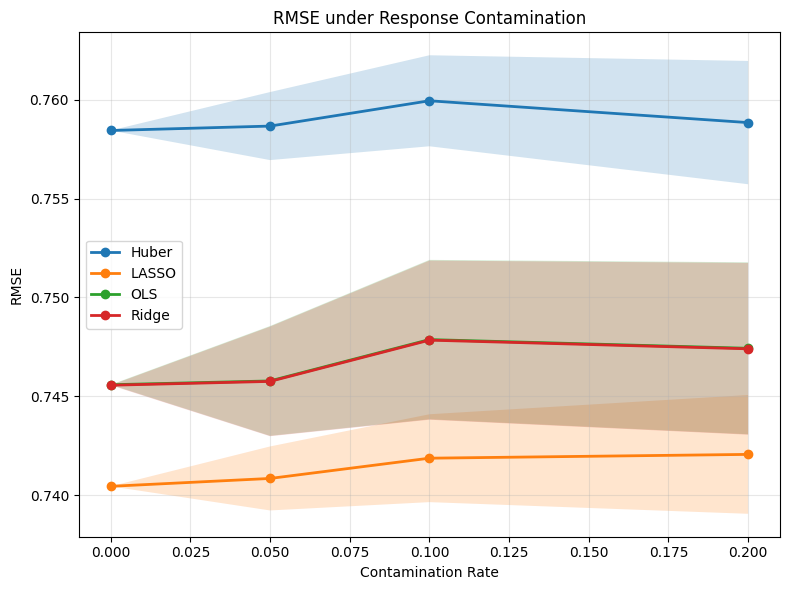

In [37]:
plt.figure(figsize=(8,6))

models = summary_df["Model"].unique()

for model in models:

    df = summary_df[
        summary_df["Model"] == model
    ]

    x = df["Contamination"]

    y = df["RMSE_mean"]

    std = df["RMSE_std"]

    plt.plot(
        x,
        y,
        marker="o",
        linewidth=2,
        label=model
    )

    plt.fill_between(
        x,
        y-std,
        y+std,
        alpha=0.2
    )

plt.xlabel("Contamination Rate")
plt.ylabel("RMSE")
plt.title("RMSE under Response Contamination")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    "rmse_response.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

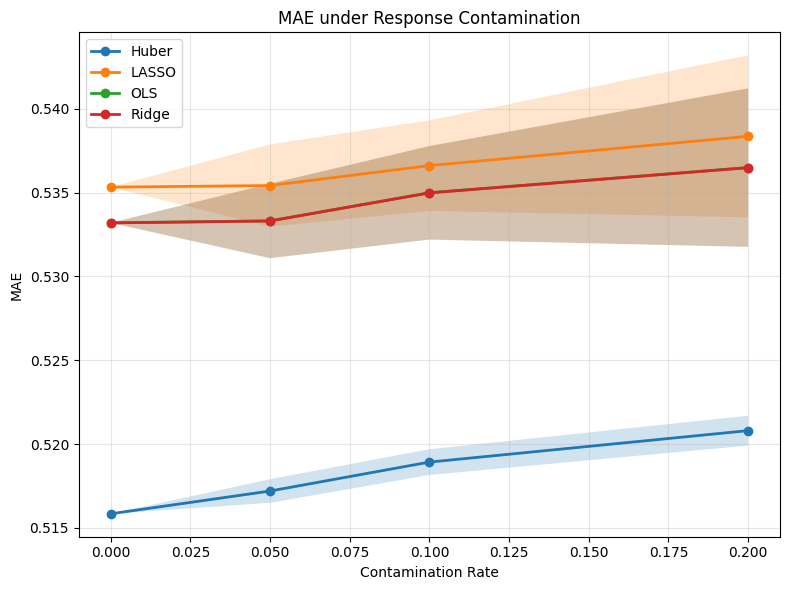

In [38]:
plt.figure(figsize=(8,6))

for model in models:

    df = summary_df[
        summary_df["Model"] == model
    ]

    x = df["Contamination"]

    y = df["MAE_mean"]

    std = df["MAE_std"]

    plt.plot(
        x,
        y,
        marker="o",
        linewidth=2,
        label=model
    )

    plt.fill_between(
        x,
        y-std,
        y+std,
        alpha=0.2
    )

plt.xlabel("Contamination Rate")
plt.ylabel("MAE")
plt.title("MAE under Response Contamination")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    "mae_response.png",
    dpi=300
)

plt.show()

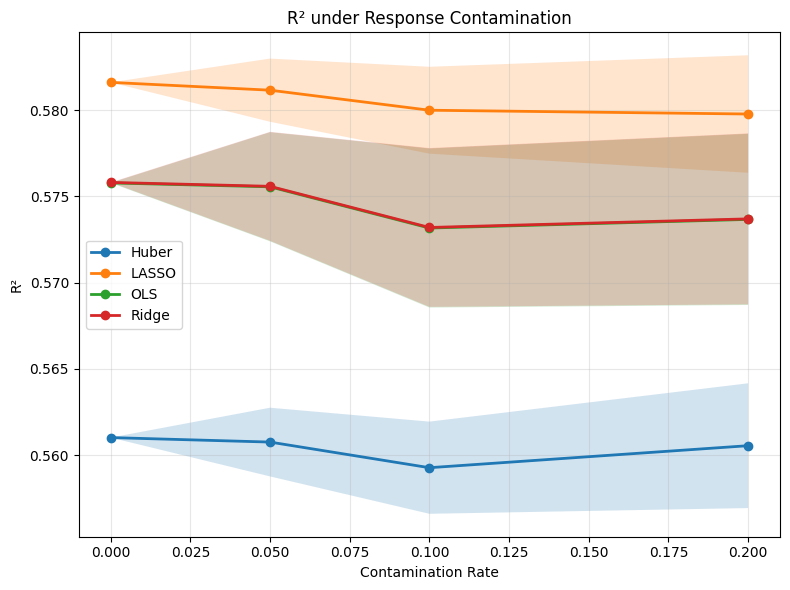

In [39]:
plt.figure(figsize=(8,6))

for model in models:

    df = summary_df[
        summary_df["Model"] == model
    ]

    x = df["Contamination"]

    y = df["R2_mean"]

    std = df["R2_std"]

    plt.plot(
        x,
        y,
        marker="o",
        linewidth=2,
        label=model
    )

    plt.fill_between(
        x,
        y-std,
        y+std,
        alpha=0.2
    )

plt.xlabel("Contamination Rate")
plt.ylabel("R²")
plt.title("R² under Response Contamination")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    "r2_response.png",
    dpi=300
)

plt.show()

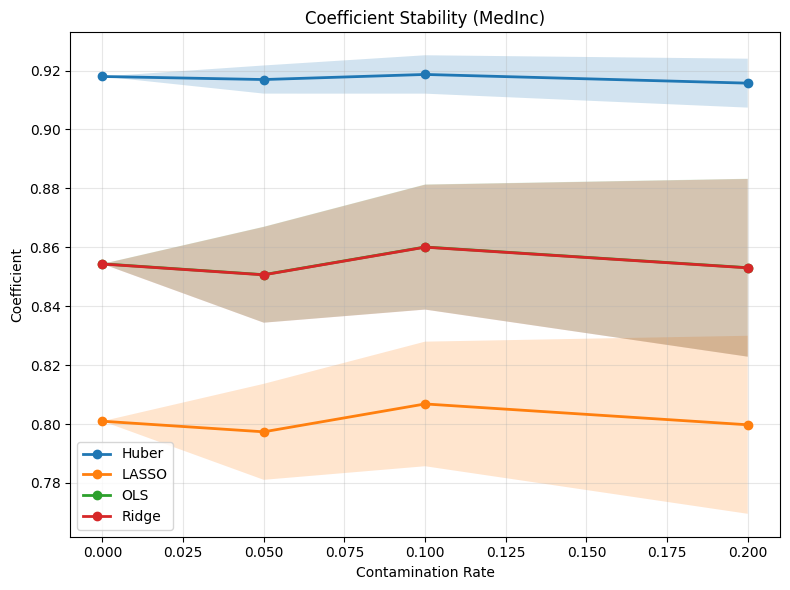

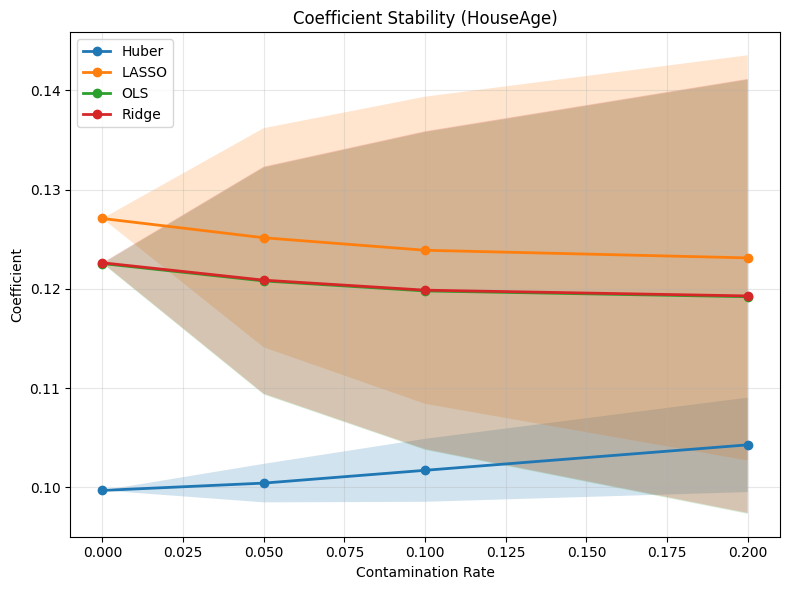

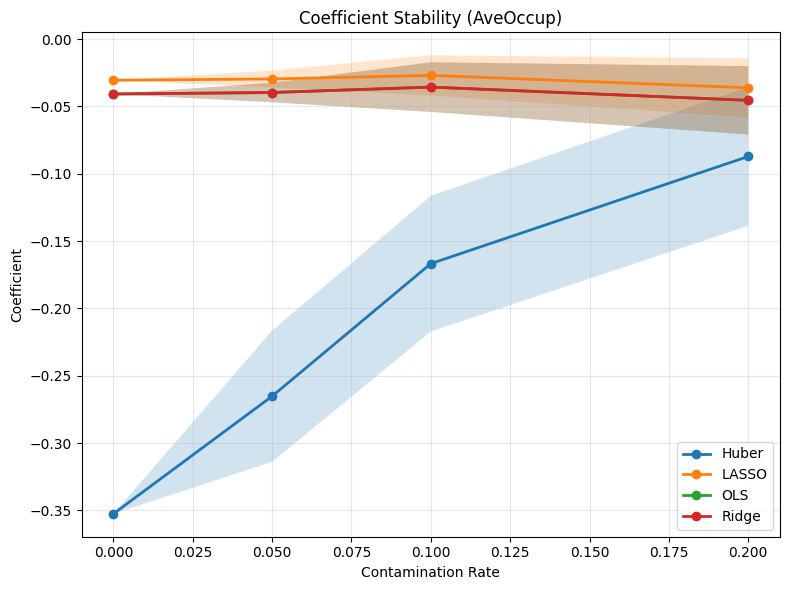

In [40]:
features = [
    "MedInc",
    "HouseAge",
    "AveOccup"
]

for feature in features:

    plt.figure(figsize=(8,6))

    for model in coef_summary["Model"].unique():

        df = coef_summary[
            coef_summary["Model"] == model
        ]

        x = df["Contamination"]

        mean = df[f"{feature}_mean"]

        std = df[f"{feature}_std"]

        plt.plot(
            x,
            mean,
            marker="o",
            linewidth=2,
            label=model
        )

        plt.fill_between(
            x,
            mean-std,
            mean+std,
            alpha=0.2
        )

    plt.xlabel("Contamination Rate")

    plt.ylabel("Coefficient")

    plt.title(
        f"Coefficient Stability ({feature})"
    )

    plt.grid(alpha=0.3)

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        f"coef_{feature}.png",
        dpi=300
    )

    plt.show()

In [41]:
rate = 0.20

seed = 0

y_train_cont = contaminate_response(
    y_train,
    rate,
    multiplier=5,
    random_state=seed
)

ols = LinearRegression()

huber = HuberRegressor()

ols.fit(
    X_train_scaled,
    y_train_cont
)

huber.fit(
    X_train_scaled,
    y_train_cont
)

ols_pred = ols.predict(
    X_test_scaled
)

huber_pred = huber.predict(
    X_test_scaled
)

ols_res = y_test - ols_pred

huber_res = y_test - huber_pred

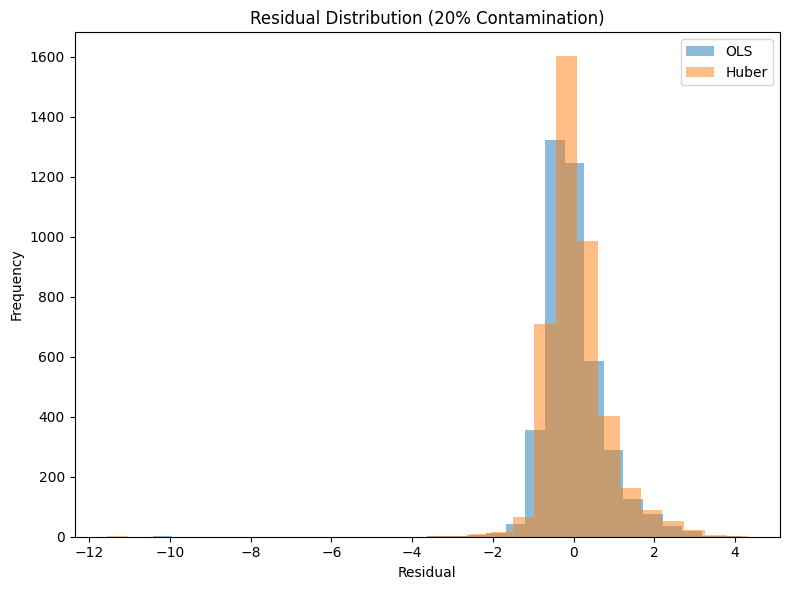

In [42]:
plt.figure(figsize=(8,6))

plt.hist(
    ols_res,
    bins=30,
    alpha=0.5,
    label="OLS"
)

plt.hist(
    huber_res,
    bins=30,
    alpha=0.5,
    label="Huber"
)

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.title(
    "Residual Distribution (20% Contamination)"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "residual_distribution.png",
    dpi=300
)

plt.show()

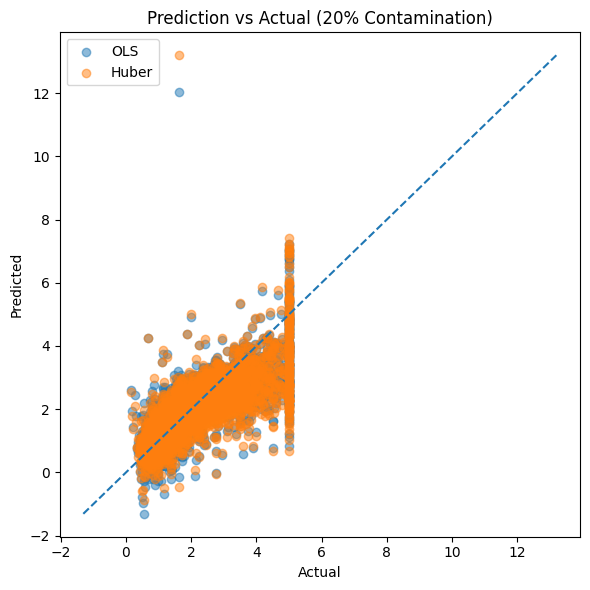

In [43]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    ols_pred,
    alpha=0.5,
    label="OLS"
)

plt.scatter(
    y_test,
    huber_pred,
    alpha=0.5,
    label="Huber"
)

mn = min(y_test.min(), ols_pred.min(), huber_pred.min())
mx = max(y_test.max(), ols_pred.max(), huber_pred.max())

plt.plot(
    [mn, mx],
    [mn, mx],
    "--"
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title(
    "Prediction vs Actual (20% Contamination)"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "prediction_vs_actual.png",
    dpi=300
)

plt.show()

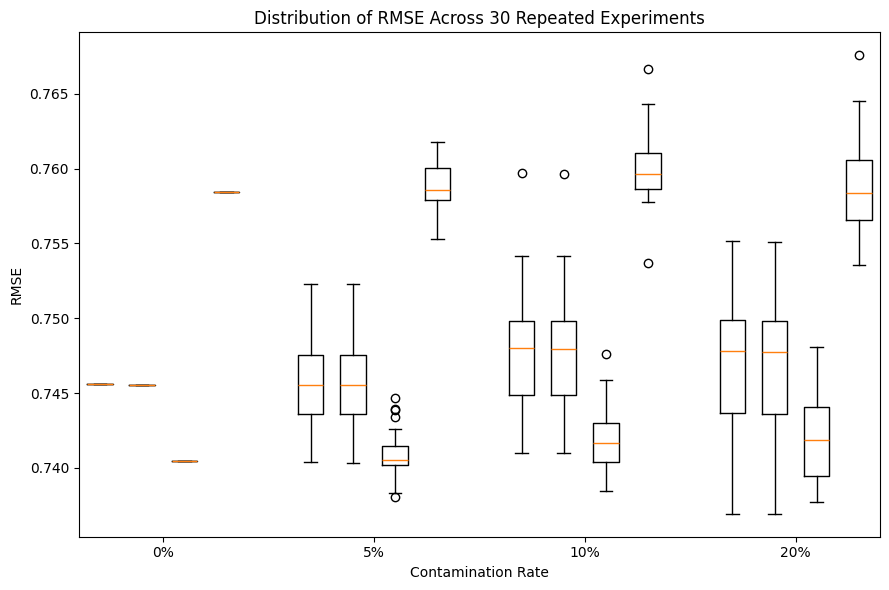

In [44]:
fig, ax = plt.subplots(figsize=(9, 6))

levels = sorted(results_df["Contamination"].unique())
models = ["OLS", "Ridge", "LASSO", "Huber"]

positions = []
data = []
labels = []

gap = 1
width = 0.18

for i, level in enumerate(levels):
    base = i * (len(models) + gap)
    for j, model in enumerate(models):
        positions.append(base + j)
        data.append(
            results_df[
                (results_df["Contamination"] == level) &
                (results_df["Model"] == model)
            ]["RMSE"].values
        )
        labels.append(model)

ax.boxplot(data, positions=positions, widths=0.6)

centers = [
    i * (len(models) + gap) + (len(models)-1)/2
    for i in range(len(levels))
]

ax.set_xticks(centers)
ax.set_xticklabels([f"{int(l*100)}%" for l in levels])

ax.set_xlabel("Contamination Rate")
ax.set_ylabel("RMSE")
ax.set_title("Distribution of RMSE Across 30 Repeated Experiments")

plt.tight_layout()

plt.savefig(
    "rmse_boxplot.png",
    dpi=300
)

plt.show()